# Analisis para lograr predecir la variable Depth to Groundwater de la base de datos AUSER

In [3]:
import pandas as pd

# Cargar el CSV
df_auser = pd.read_csv("/workspaces/LucasDellaMaestra-SeriesTemporales2/data/raw/Aquifer_Auser.csv")

# Mostrar las primeras filas
df_auser.head()


,Date,Rainfall_Gallicano,Rainfall_Pontetetto,Rainfall_Monte_Serra,Rainfall_Orentano,Rainfall_Borgo_a_Mozzano,Rainfall_Piaggione,Rainfall_Calavorno,Rainfall_Croce_Arcana,Rainfall_Tereglio_Coreglia_Antelminelli,...,Temperature_Monte_Serra,Temperature_Ponte_a_Moriano,Temperature_Lucca_Orto_Botanico,Volume_POL,Volume_CC1,Volume_CC2,Volume_CSA,Volume_CSAL,Hydrometry_Monte_S_Quirico,Hydrometry_Piaggione
0,05/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,06/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,10.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,07/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.2,0.0,10.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,08/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.4,0.0,13.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,09/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.4,0.0,12.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Primer análisis general
### inspeccionar la estructura del dataset:

In [4]:
# Tamaño del dataset
print(f"Filas: {df_auser.shape[0]}, Columnas: {df_auser.shape[1]}")

# Tipos de datos y nulos
print(df_auser.info())

# Estadísticas generales
print(df_auser.describe())


Filas: 8154, Columnas: 27
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8154 entries, 0 to 8153
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Date                                     8154 non-null   object 
 1   Rainfall_Gallicano                       5295 non-null   float64
 2   Rainfall_Pontetetto                      5295 non-null   float64
 3   Rainfall_Monte_Serra                     5289 non-null   float64
 4   Rainfall_Orentano                        5295 non-null   float64
 5   Rainfall_Borgo_a_Mozzano                 5295 non-null   float64
 6   Rainfall_Piaggione                       4930 non-null   float64
 7   Rainfall_Calavorno                       5295 non-null   float64
 8   Rainfall_Croce_Arcana                    5295 non-null   float64
 9   Rainfall_Tereglio_Coreglia_Antelminelli  5295 non-null   float64
 10  Rainfall_Fabbriche_di_

### Revisar Valores Nulos

In [5]:
# Ver nulos por columna
print(df_auser.isnull().sum())

Date                                          0
Rainfall_Gallicano                         2859
Rainfall_Pontetetto                        2859
Rainfall_Monte_Serra                       2865
Rainfall_Orentano                          2859
Rainfall_Borgo_a_Mozzano                   2859
Rainfall_Piaggione                         3224
Rainfall_Calavorno                         2859
Rainfall_Croce_Arcana                      2859
Rainfall_Tereglio_Coreglia_Antelminelli    2859
Rainfall_Fabbriche_di_Vallico              2859
Depth_to_Groundwater_LT2                   3352
Depth_to_Groundwater_SAL                   3609
Depth_to_Groundwater_PAG                   4347
Depth_to_Groundwater_CoS                   3839
Depth_to_Groundwater_DIEC                  4884
Temperature_Orentano                          0
Temperature_Monte_Serra                       0
Temperature_Ponte_a_Moriano                   0
Temperature_Lucca_Orto_Botanico               0
Volume_POL                              

### Graficar la variable objetivo

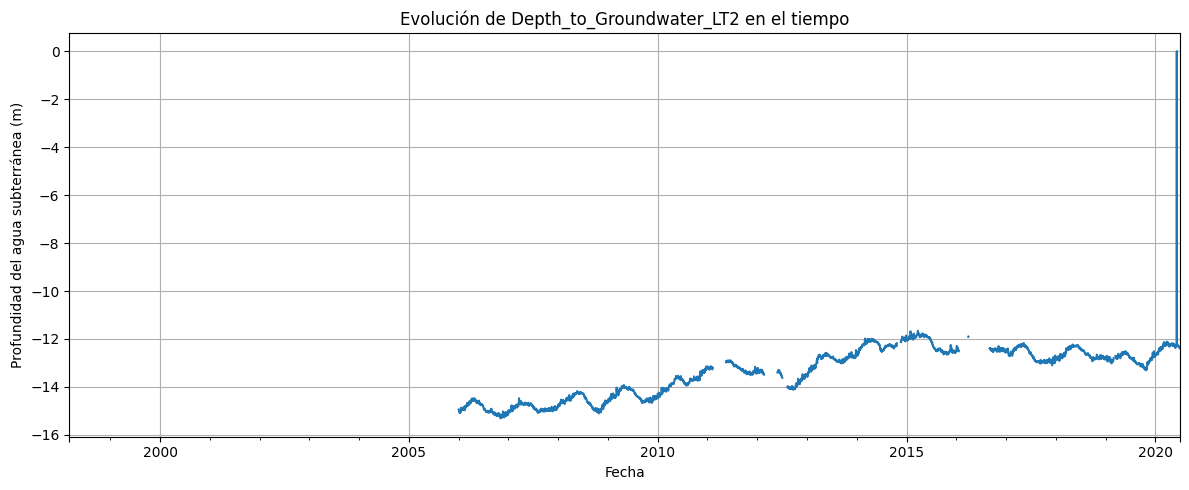

In [6]:
import matplotlib.pyplot as plt

df_auser['Date'] = pd.to_datetime(df_auser['Date'], dayfirst=True)

# Establecer la fecha como índice
df_auser.set_index('Date', inplace=True)

# Graficar la serie temporal de la variable objetivo (Depth_to_Groundwater_LT2)
plt.figure(figsize=(12, 5))
df_auser['Depth_to_Groundwater_LT2'].plot()
plt.title('Evolución de Depth_to_Groundwater_LT2 en el tiempo')
plt.xlabel('Fecha')
plt.ylabel('Profundidad del agua subterránea (m)')
plt.grid(True)
plt.tight_layout()
plt.show()


### Histograma de distribución de valores

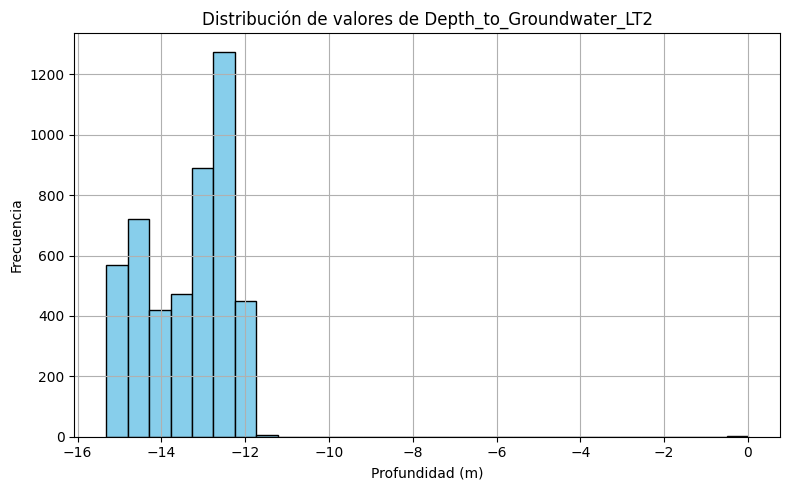

In [7]:
plt.figure(figsize=(8, 5))
df_auser['Depth_to_Groundwater_LT2'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de valores de Depth_to_Groundwater_LT2')
plt.xlabel('Profundidad (m)')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.tight_layout()
plt.show()


### Boxplot por año para detectar estacionalidad/anomalías

<Figure size 1000x500 with 0 Axes>

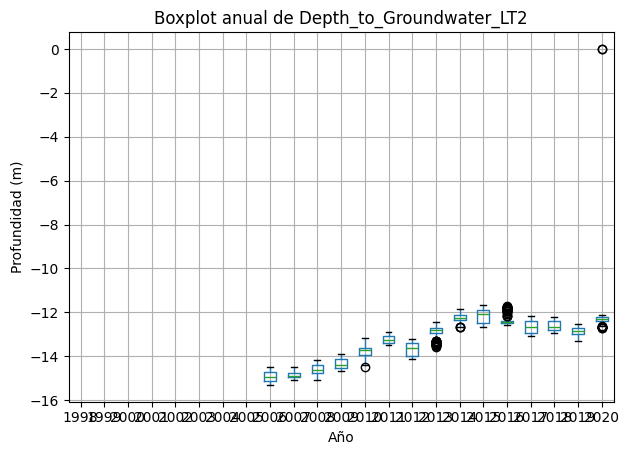

In [8]:
df_auser['year'] = df_auser.index.year

plt.figure(figsize=(10, 5))
df_auser.boxplot(column='Depth_to_Groundwater_LT2', by='year', grid=True)
plt.title('Boxplot anual de Depth_to_Groundwater_LT2')
plt.suptitle('')
plt.xlabel('Año')
plt.ylabel('Profundidad (m)')
plt.tight_layout()
plt.show()


## Ahora preparamos los datos para modelar

### Filtrar la serie objetivo

### Rellenar valores nulos (interpolación temporal)

### Separar en train y test (por tiempo)

In [9]:
# 1. Selección de la serie objetivo
serie = df_auser['Depth_to_Groundwater_LT2']

# 2. Interpolación para valores nulos
serie_interp = serie.interpolate(method='time')

# 3. División train/test (80% train, 20% test)
split_index = int(len(serie_interp) * 0.8)
train_series = serie_interp[:split_index]
test_series = serie_interp[split_index:]

print(f"Train: {train_series.index[0].date()} → {train_series.index[-1].date()}")
print(f"Test: {test_series.index[0].date()} → {test_series.index[-1].date()}")


Train: 1998-03-05 → 2016-01-12
Test: 2016-01-13 → 2020-06-30


# Prueba con Modelo Random Forest para series temporales

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np

# Crear features de lags
def create_lagged_features(series, n_lags=10):
    df = pd.DataFrame(series)
    for lag in range(1, n_lags + 1):
        df[f'lag_{lag}'] = df[series.name].shift(lag)
    df = df.dropna()
    return df

# Crear features de lags
df_lags = create_lagged_features(serie_interp, n_lags=10)

# División en X e y
X = df_lags.drop(columns=['Depth_to_Groundwater_LT2'])
y = df_lags['Depth_to_Groundwater_LT2']

# split_index ajustado a la longitud de df_lags
split_index = int(len(df_lags) * 0.8)

# División en train y test
X_train_rf = X[:split_index]
y_train_rf = y[:split_index]
X_test_rf = X[split_index:]
y_test_rf = y[split_index:]

### Entrenamiento y guardado del modelo Random Forest

In [12]:
# Entrenamiento
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

RandomForestRegressor(random_state=42)

In [13]:
# Predicción
y_pred_rf = rf_model.predict(X_test_rf)

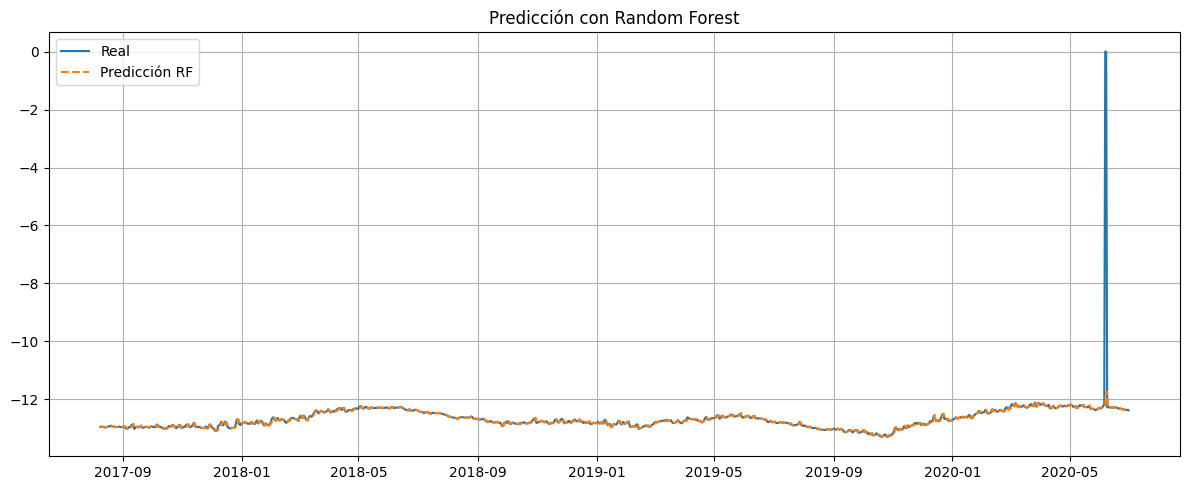

In [14]:
# Visualización
plt.figure(figsize=(12, 5))
plt.plot(y_test_rf.index, y_test_rf, label='Real')
plt.plot(y_test_rf.index, y_pred_rf, label='Predicción RF', linestyle='--')
plt.title('Predicción con Random Forest')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
import joblib

# Guardar el modelo
joblib.dump(rf_model, 'model_random_forest.pkl')

['model_random_forest.pkl']

# Cálculo de métricas

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Métricas
mae = mean_absolute_error(y_test_rf, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
r2 = r2_score(y_test_rf, y_pred_rf)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")


MAE: 0.0503
RMSE: 0.5225
R²: 0.2743


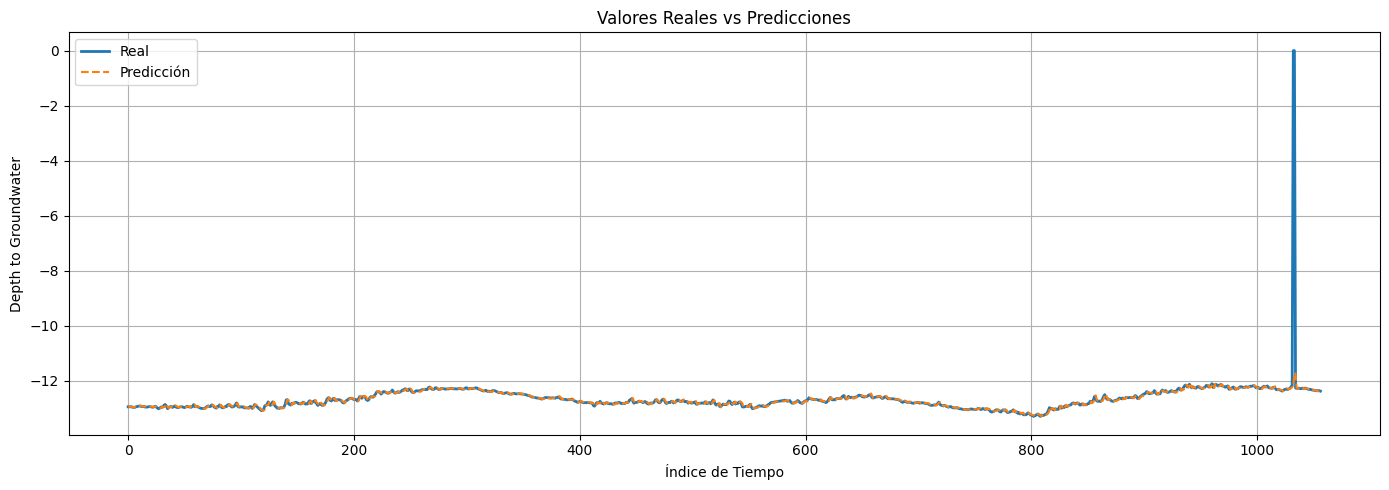

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(y_test_rf.reset_index(drop=True), label="Real", linewidth=2)
plt.plot(y_pred_rf, label="Predicción", linestyle='--')
plt.title("Valores Reales vs Predicciones")
plt.xlabel("Índice de Tiempo")
plt.ylabel("Depth to Groundwater")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
